### Setup

Garante que o DuckDB está instalado no ambiente do Colab (aqui ele já veio pronto — só confirma).

In [1]:
# Instala o DuckDB no ambiente do Colab (aqui ja diz "already satisfied" - so garante que existe)
pip install duckdb

### Carregando os dados da Bronze

Abre a conexão com o DuckDB e aponta para os arquivos parquet que você enviou pro Colab (pasta `/content`). Confirma quantas linhas foram carregadas (deve bater com o `TOTAL_SAMPLES` do `ingest.py` — aqui deu 50.000, ou seja, os dados reais chegaram certinho) e mostra as 5 primeiras linhas só pra conferir visualmente o formato (`label`, `title`, `content`).

In [3]:
import duckdb
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path

plt.rcParams["figure.facecolor"] = "white"  # fundo branco nos graficos (Colab as vezes usa fundo escuro)

# Aponta para TODOS os arquivos parquet dentro de /content (onde ficam os arquivos que voce
# fez upload/colou no Colab) - o "*" pega qualquer part-*.parquet que estiver la
BRONZE_GLOB = str(Path("/content") / "*.parquet")

con = duckdb.connect()  # conexao DuckDB em memoria, so pra rodar as consultas desta sessao
bronze = f"read_parquet('{BRONZE_GLOB}')"  # isso NAO carrega nada ainda - e so a definicao de
                                            # "leia esses parquet como uma tabela so", usada dentro
                                            # de cada query abaixo

total = con.sql(f"SELECT count(*) FROM {bronze}").fetchone()[0]
print(f"{total} linhas carregadas de {BRONZE_GLOB}")
con.sql(f"SELECT * FROM {bronze} LIMIT 5").df()  # espia as 5 primeiras linhas pra conferir o formato

50000 linhas carregadas de /content/*.parquet


,label,title,content
0,0,commercial shlock,This is a poorly written and poorly directed f...
1,1,An honest and personal accoount,This book is a very quick read because the tel...
2,1,FROM COMEDY TO UNDERSTANDING OVER A 30 YEAR CA...,I READ THIS BOOK SHORTLY AFTER DOING MY INTERN...
3,1,So far so good,This is our 2nd electric kettle. We had a Brev...
4,0,Too cheap...,The idea was to get an inexpensive watch for u...


### Balanceamento de classes

Conta quantas linhas existem para cada rótulo (0=negativo, 1=positivo). Isso importa porque decide se `accuracy` sozinha é uma métrica confiável lá na frente (Etapa 5) — se o dataset viesse muito desbalanceado, precisaríamos olhar precision/recall/F1 por classe em vez de só acurácia geral.

,classe,n
0,negativo,24684
1,positivo,25316


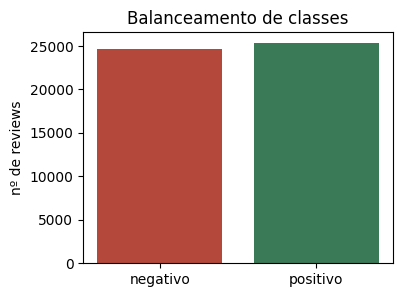

In [5]:
# Conta quantas linhas existem pra cada rotulo (0=negativo, 1=positivo)
counts_df = con.sql(f"""
    SELECT label, count(*) AS n FROM {bronze} GROUP BY label ORDER BY label
""").df()
counts_df["classe"] = counts_df["label"].map({0: "negativo", 1: "positivo"})  # so pra ficar legivel
display(counts_df[["classe", "n"]])

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(counts_df["classe"], counts_df["n"], color=["#B4483B", "#3B7A57"])  # vermelho=negativo, verde=positivo
ax.set_title("Balanceamento de classes")
ax.set_ylabel("nº de reviews")
plt.show()

### Nulos e duplicatas

Checagem de qualidade: quantas linhas têm campo essencial faltando (`label`/`title`/`content` nulos) e quantos reviews têm texto (`content`) exatamente repetido. É essa checagem que justifica os filtros que existem depois na Silver (`process.py`) — lá removemos exatamente o que aparecer aqui.

In [6]:
# Conta quantos valores nulos existem em cada coluna essencial
nulls_df = con.sql(f"""
    SELECT
        sum(CASE WHEN label   IS NULL THEN 1 ELSE 0 END) AS label_nulls,
        sum(CASE WHEN title   IS NULL THEN 1 ELSE 0 END) AS title_nulls,
        sum(CASE WHEN content IS NULL THEN 1 ELSE 0 END) AS content_nulls
    FROM {bronze}
""").df()
print("Nulos por coluna:")
display(nulls_df)

# count(*) - count(DISTINCT content) = quantas linhas "a mais" existem alem de uma copia
# unica de cada texto -> isso e o numero de duplicatas
dup = con.sql(f"SELECT count(*) - count(DISTINCT content) AS duplicatas FROM {bronze}").fetchone()[0]
print(f"Reviews com texto duplicado: {dup} ({dup/total:.1%} do total)")

Nulos por coluna:


,label_nulls,title_nulls,content_nulls
0,0.0,0.0,0.0


Reviews com texto duplicado: 13 (0.0% do total)


### Tamanho dos reviews (caracteres)

Calcula estatísticas resumo (mínimo, média, mediana, máximo) e desenha a distribuição completa num histograma. Serve pra achar reviews quebrados/vazios (mínimo muito baixo), outliers gigantes (máximo muito acima da média) e ver se a distribuição é assimétrica (média bem diferente da mediana) — isso influencia decisões de vetorização (TF-IDF) mais na frente.

,min,media,mediana,max
0,32,404.1,354.0,1006


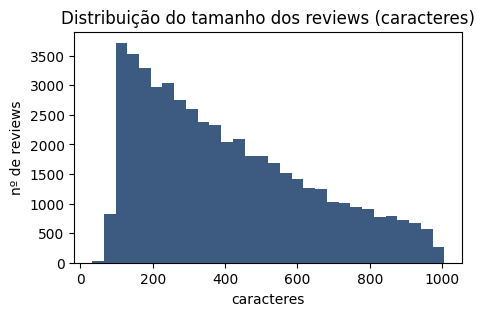

In [7]:
# Estatisticas de tamanho do review, em numero de caracteres
stats_df = con.sql(f"""
    SELECT
        min(length(content))            AS min,
        round(avg(length(content)), 1)  AS media,
        median(length(content))          AS mediana,
        max(length(content))            AS max
    FROM {bronze}
""").df()
display(stats_df)

# pega o tamanho de CADA review individualmente (nao agregado) pra desenhar a distribuicao inteira
lengths = con.sql(f"SELECT length(content) AS len_chars FROM {bronze}").df()["len_chars"]
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(lengths, bins=30, color="#3D5A80")
ax.set_title("Distribuição do tamanho dos reviews (caracteres)")
ax.set_xlabel("caracteres")
ax.set_ylabel("nº de reviews")
plt.show()

### Palavras mais frequentes por classe (amostra)

Conta as palavras mais comuns em negativos e positivos, numa amostra de 5000 reviews (não precisa do dataset inteiro pra uma checagem visual de vocabulário). Serve pra confirmar se existe diferença de vocabulário real entre as classes.

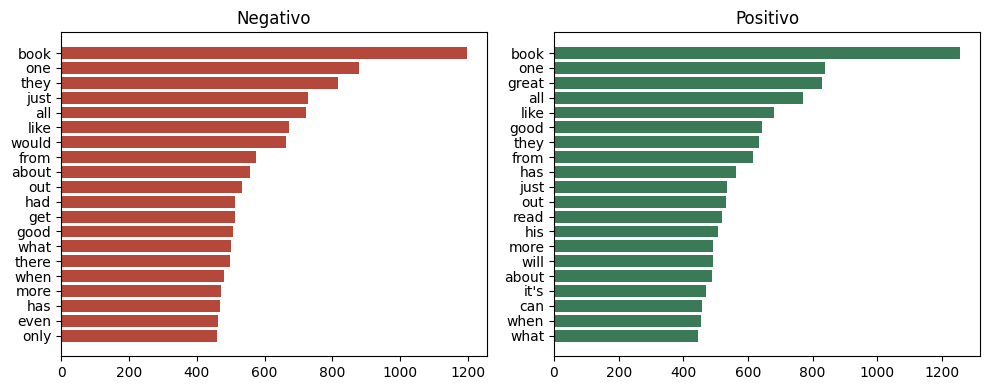

In [9]:
# Palavras muito genericas (artigos, preposicoes, pronomes) que nao carregam sentimento -
# sao ignoradas na contagem abaixo pra sobrar so palavra que realmente diz alguma coisa
STOPWORDS = {
    "the", "a", "an", "and", "or", "to", "of", "is", "it", "this", "in", "for",
    "i", "was", "on", "with", "my", "that", "are", "have", "but", "so", "not",
    "you", "me", "as", "be", "at", "very",
}

def top_words(texts, n=20):
    """Conta as palavras mais frequentes numa lista de textos, ignorando STOPWORDS
    e palavras muito curtas (<=2 letras)."""
    counter = Counter()
    for t in texts:
        words = re.findall(r"[a-z']+", str(t).lower())
        counter.update(w for w in words if w not in STOPWORDS and len(w) > 2)
    return counter.most_common(n)

# so uma amostra de 5000 linhas - e uma checagem visual de vocabulario, nao precisa do dataset inteiro
sample = con.sql(f"SELECT label, content FROM {bronze} USING SAMPLE 5000 ROWS").df()
neg_top = top_words(sample.loc[sample["label"] == 0, "content"])
pos_top = top_words(sample.loc[sample["label"] == 1, "content"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, top, title, color in [
    (axes[0], neg_top, "Negativo", "#B4483B"),
    (axes[1], pos_top, "Positivo", "#3B7A57"),
]:
    # reversed() + zip(*...) : inverte a ordem (menos frequente primeiro) e separa
    # em duas listas (palavras, frequencias), porque o barh desenha de baixo pra cima -
    # sem inverter, a palavra mais frequente apareceria embaixo do grafico
    words, freqs = zip(*reversed(top))
    ax.barh(words, freqs, color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Tamanho do review por classe

Mesma ideia da célula de tamanho acima, mas separado por classe — serve pra ver se um lado tende a escrever mais que o outro (por exemplo, reclamação costuma vir mais detalhada que elogio).

/tmp/ipykernel_9316/2939255658.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


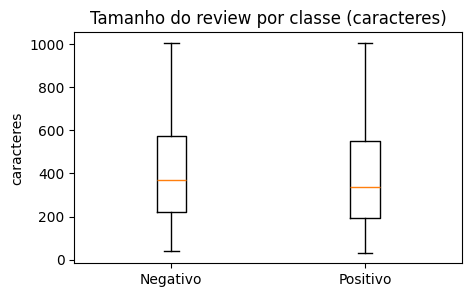

In [11]:
# Mesma ideia da celula de tamanho (acima), mas agora separado por classe -
# serve pra ver se negativo e positivo tendem a ter tamanhos diferentes
lengths_df = con.sql(f"""
    SELECT label, length(content) AS len_chars
    FROM {bronze}
""").df()

fig, ax = plt.subplots(figsize=(5, 3))
ax.boxplot(
    [lengths_df.loc[lengths_df["label"] == 0, "len_chars"],
     lengths_df.loc[lengths_df["label"] == 1, "len_chars"]],
    labels=["Negativo", "Positivo"],
    showfliers=False,  # esconde outliers extremos pra nao achatar a escala do grafico
)
ax.set_title("Tamanho do review por classe (caracteres)")
ax.set_ylabel("caracteres")
plt.show()

### Bigramas (pares de palavras) mais frequentes por classe

Em vez de olhar palavra por palavra, agrupa pares de palavras consecutivas. Pares carregam sentimento de forma mais clara que palavras soltas — é o que a tabela de tradução na célula seguinte está mostrando: termos como `waste money`, `highly recommend` já deixam a classe bem mais óbvia do que qualquer palavra isolada.

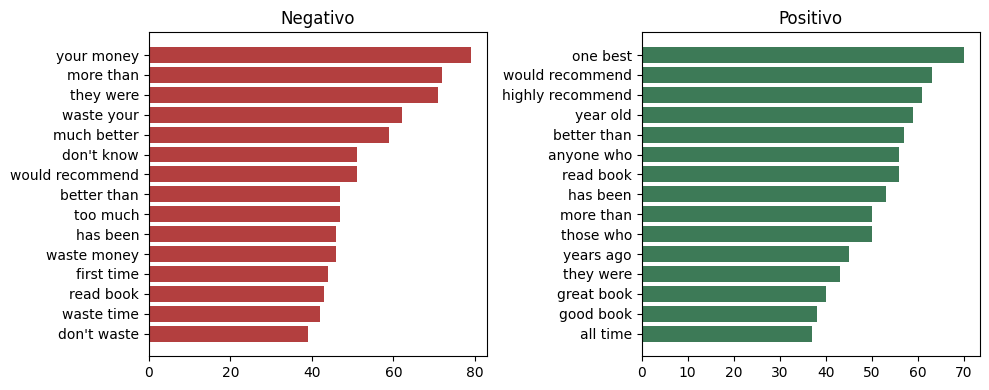

In [12]:
def top_bigrams(texts, n=15):
    """Igual ao top_words, mas em vez de palavra isolada, conta PARES de palavras
    consecutivas (ex: "waste your", "highly recommend") - pares tendem a carregar
    sentimento de forma mais clara do que uma palavra sozinha."""
    counter = Counter()
    for t in texts:
        words = [w for w in re.findall(r"[a-z']+", str(t).lower()) if w not in STOPWORDS and len(w) > 2]
        # zip(words, words[1:]) forma os pares consecutivos: (palavra1,palavra2), (palavra2,palavra3), ...
        counter.update(" ".join(par) for par in zip(words, words[1:]))
    return counter.most_common(n)

sample_bg = con.sql(f"SELECT label, content FROM {bronze} USING SAMPLE 5000 ROWS").df()
neg_bigrams = top_bigrams(sample_bg.loc[sample_bg["label"] == 0, "content"])
pos_bigrams = top_bigrams(sample_bg.loc[sample_bg["label"] == 1, "content"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, top, title, color in [
    (axes[0], neg_bigrams, "Negativo", "#B33F3F"),
    (axes[1], pos_bigrams, "Positivo", "#3D7A57"),
]:
    words, freqs = zip(*reversed(top))
    ax.barh(words, freqs, color=color)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Principais termos em avaliações negativas

| Inglês | Português |
|---|---|
| `your money` | seu dinheiro |
| `more than` | mais do que |
| `they were` | eles eram / estavam |
| `waste your` | desperdice seu |
| `much better` | muito melhor |
| `don't know` | não sei |
| `would recommend` | recomendaria |
| `better than` | melhor do que |
| `too much` | demais / muito |
| `has been` | tem sido / foi |
| `waste money` | desperdiçar dinheiro |
| `first time` | primeira vez |
| `read book` | ler livro |
| `waste time` | perder tempo |
| `don't waste` | não desperdice |

###Principais termos em avaliações positivas

| Inglês | Português |
|---|---|
| `one best` | um dos melhores |
| `would recommend` | recomendaria |
| `highly recommend` | recomendo muito |
| `year old` | anos de idade |
| `better than` | melhor do que |
| `anyone who` | qualquer pessoa que |
| `read book` | ler livro |
| `has been` | tem sido / foi |
| `more than` | mais do que |
| `those who` | aqueles que |
| `years ago` | anos atrás |
| `they were` | eles eram / estavam |
| `great book` | ótimo livro |
| `good book` | bom livro |
| `all time` | de todos os tempos |